<div style="border-left:6px solid #2a78d6;padding:14px 20px;background:#f4f8fd;border-radius:6px">
<p style="margin:0;color:#52514e;font-size:13px">Data Analytics Básico · Módulo 16 — Análisis avanzado</p>
<h1 style="margin:6px 0 0 0;color:#0b0b0b">16. Evaluación de Modelos y Decisiones de Negocio</h1>
<p style="margin:8px 0 0 0;color:#52514e">El paso que convierte un modelo en una decisión: elegir la métrica correcta, mover el umbral según el <strong>costo de cada error</strong>, y traducir todo a una recomendación ejecutiva.</p>
</div>

> ### Antes de empezar
>
> Ya sabes construir modelos (notebooks 14 y 15). Este cierra el bloque con lo que separa a un analista de datos de un buen analista de **negocio**: evaluar un modelo pensando en su impacto real.
>
> Verás que una sola métrica engaña, que **mover el umbral de decisión** puede valer más que cambiar de modelo, y cómo convertir métricas técnicas en una recomendación que un comité entienda. La pregunta que guía todo: *¿qué error es más caro para el negocio?*

Cargamos las librerías:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, mean_absolute_error, root_mean_squared_error, r2_score
)

sns.set_theme(style='whitegrid')
np.random.seed(42)

print('Notebook 16 listo: Evaluación y decisiones de negocio')

Notebook 16 listo: Evaluación y decisiones de negocio


## Introducción

### ¿Qué es?
Evaluar modelos significa medir su desempeño técnico y, al mismo tiempo, interpretar su impacto operativo y económico.

Una métrica aislada (por ejemplo accuracy) no siempre representa el valor real para negocio.

### ¿Para qué sirve?
Permite responder preguntas clave:
- ¿qué tipo de error es más costoso?
- ¿qué umbral de decisión conviene usar?
- ¿qué acción debería tomar el equipo con base en el modelo?

En otras palabras, conecta ciencia de datos con toma de decisiones.

### ¿Cómo se usa?
En este notebook trabajaremos tres niveles:
1. Métricas de clasificación y matriz de confusión
2. Ajuste de umbral según costos de negocio
3. Traducción de resultados a recomendación ejecutiva

## 1. Clasificación: Métricas y Matriz de Confusión

### ¿Qué es?
En clasificación binaria comparamos predicciones vs realidad para obtener:
- accuracy: porcentaje total de aciertos
- precision: calidad de los positivos predichos
- recall: cobertura de positivos reales
- F1: equilibrio entre precision y recall
- ROC AUC: capacidad de separación global por probabilidades

### ¿Para qué sirve?
Cada métrica responde una pregunta distinta.

Ejemplo en churn:
- recall bajo implica que se escapan clientes en riesgo
- precision baja implica acciones de retención sobre clientes que no se irían

Por eso no basta con mirar una sola métrica.

### ¿Cómo se usa?
Entrenamos un modelo, obtenemos probabilidades y evaluamos con umbral inicial 0.50 para establecer punto de partida.

In [2]:
# ------------------------------------------------------
# 1) Simulamos un caso de clasificacion (churn)
# ------------------------------------------------------
# La variable objetivo sera churn (1=abandona, 0=permanece).
# Generamos features con relaciones plausibles de negocio.
n = 5000
df = pd.DataFrame({
    'antiguedad': np.random.randint(1, 61, n),
    'uso': np.random.gamma(2, 7, n),
    'tickets': np.random.poisson(2.1, n),
    'plan': np.random.choice(['basico', 'plus', 'premium'], n, p=[0.55, 0.30, 0.15]),
    'canal': np.random.choice(['app', 'web', 'telefono'], n, p=[0.60, 0.30, 0.10])
})

# Funcion latente de riesgo de churn.
score = (
    -2.0
    - 0.03 * df['antiguedad']
    - 0.04 * df['uso']
    + 0.42 * (df['tickets'] >= 3).astype(int)
    + 0.30 * (df['plan'] == 'basico').astype(int)
    + 0.22 * (df['canal'] == 'telefono').astype(int)
    + np.random.normal(0, 0.55, n)
)

proba = 1 / (1 + np.exp(-score))
df['churn'] = np.random.binomial(1, proba)

# Separacion de variables
X = df.drop(columns=['churn'])
y = df['churn']

# Split estratificado para mantener proporcion de churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

num = X.select_dtypes(include=['number']).columns.tolist()
cat = X.select_dtypes(exclude=['number']).columns.tolist()

# Pipeline con preprocesamiento + modelo
pipe = Pipeline(steps=[
    ('prep', ColumnTransformer([
        ('num', StandardScaler(), num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat)
    ])),
    ('clf', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

# Probabilidades para analizar umbrales
proba_test = pipe.predict_proba(X_test)[:, 1]

# Punto de partida clasico: umbral 0.50
pred_05 = (proba_test >= 0.50).astype(int)

metricas = pd.Series({
    'accuracy': accuracy_score(y_test, pred_05),
    'precision': precision_score(y_test, pred_05, zero_division=0),
    'recall': recall_score(y_test, pred_05, zero_division=0),
    'f1': f1_score(y_test, pred_05, zero_division=0),
    'roc_auc': roc_auc_score(y_test, proba_test)
}).round(3)

print('Tasa de churn:', round(y.mean(), 3))
metricas

Tasa de churn: 0.054


,0
accuracy,0.946
precision,0.000
recall,0.000
f1,0.000
roc_auc,0.638


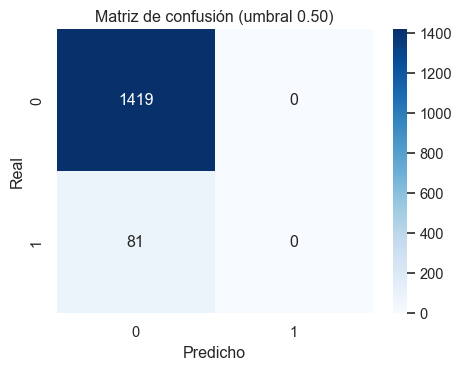

In [3]:
cm = confusion_matrix(y_test, pred_05)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión (umbral 0.50)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 1.1 El accuracy 0.95 engaña: recall = 0

Igual que en el notebook 14, con **churn del 5.4%** el modelo logra 94.6% de accuracy simplemente prediciendo que **nadie abandona**. La matriz de confusión lo confirma: cero verdaderos positivos.

Pero fíjate en el **ROC AUC ≈ 0.64**: el modelo **sí ordena** a los clientes por riesgo. Lo que falla es el **umbral de 0.5**. En un evento tan raro, el modelo casi nunca estima una probabilidad de churn mayor a 0.5, así que con ese corte no marca a nadie.

Aquí atacamos el problema con una palanca distinta a la del notebook 14: en vez de reequilibrar las clases, **bajamos el umbral de decisión** hasta un punto que tenga sentido para el negocio. Primero veamos qué tan altas llegan a ser las probabilidades:

In [4]:
# Por que el umbral 0.5 no marca a nadie: las probabilidades casi nunca lo superan
print('Distribución de la probabilidad estimada de churn (test):')
print(pd.Series(proba_test).describe().round(3))
print()
print('Probabilidad máxima estimada: {:.3f}'.format(proba_test.max()))
print('Clientes con proba >= 0.50: {} de {}'.format(int((proba_test >= 0.5).sum()), len(proba_test)))

Distribución de la probabilidad estimada de churn (test):
count    1500.000
mean        0.053
std         0.037
min         0.003
25%         0.025
50%         0.043
75%         0.072
max         0.230
dtype: float64

Probabilidad máxima estimada: 0.230
Clientes con proba >= 0.50: 0 de 1500


## 2. Umbral de Decisión y Costo de Negocio

### ¿Qué es?
El umbral convierte probabilidades en decisiones binarias.

Si probabilidad >= umbral => acción positiva
Si probabilidad < umbral => acción negativa

### ¿Para qué sirve?
Cambiar el umbral altera el balance entre falsos positivos y falsos negativos.
Como ambos errores no cuestan igual, el mejor umbral depende del contexto de negocio.

### ¿Cómo se usa?
1. Definimos una función de costo
2. Probamos varios umbrales
3. Elegimos el de menor costo total esperado

Esta es una de las prácticas más útiles para pasar de modelado técnico a impacto económico.

In [5]:
# ------------------------------------------------------
# 2) Analisis de umbral con funcion de costo
# ------------------------------------------------------
# Supuesto de negocio:
# - Falso negativo (no detectar churn): costo alto
# - Falso positivo (accion innecesaria): costo bajo
costo_fn = 220
costo_fp = 25

def costo_total(y_true, y_pred, costo_fn=220, costo_fp=25):
    cm = confusion_matrix(y_true, y_pred)
    fp = cm[0, 1]
    fn = cm[1, 0]
    return fp * costo_fp + fn * costo_fn

# Exploramos desde umbrales bajos: con un evento raro, el corte util
# suele estar muy por debajo de 0.5.
umbrales = np.arange(0.05, 0.81, 0.05)
registros = []

for t in umbrales:
    pred_t = (proba_test >= t).astype(int)
    registros.append({
        'umbral': round(t, 2),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall': recall_score(y_test, pred_t, zero_division=0),
        'f1': f1_score(y_test, pred_t, zero_division=0),
        'costo_total_usd': costo_total(y_test, pred_t, costo_fn, costo_fp)
    })

# Tabla comparativa para elegir la estrategia mas rentable.
df_umb = pd.DataFrame(registros)
df_umb.sort_values('costo_total_usd').head()

,umbral,precision,recall,f1,costo_total_usd
1,0.10,0.118919,0.271605,0.165414,17055
2,0.15,0.131579,0.061728,0.084034,17545
3,0.20,0.500000,0.012346,0.024096,17625
4,0.25,0.000000,0.000000,0.000000,17820
6,0.35,0.000000,0.000000,0.000000,17820


Mejor umbral: 0.1
Costo mínimo estimado (USD): 17055


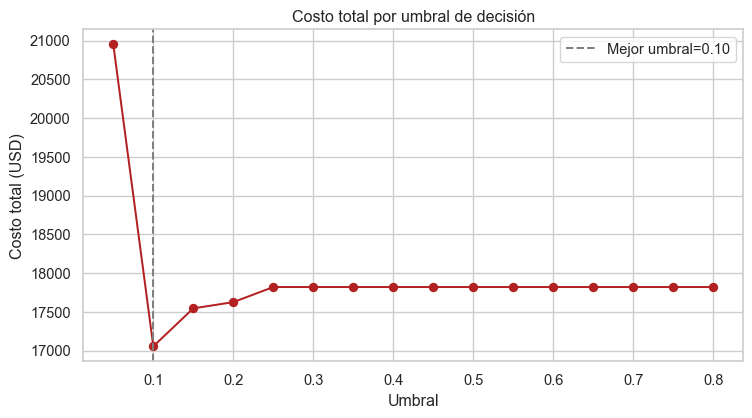

In [6]:
best = df_umb.sort_values('costo_total_usd').iloc[0]
best_t = float(best['umbral'])

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(df_umb['umbral'], df_umb['costo_total_usd'], marker='o', color='firebrick')
ax1.axvline(best_t, color='gray', linestyle='--', label=f'Mejor umbral={best_t:.2f}')
ax1.set_title('Costo total por umbral de decisión')
ax1.set_xlabel('Umbral')
ax1.set_ylabel('Costo total (USD)')
ax1.legend()
plt.tight_layout()
plt.show()

print('Mejor umbral:', best_t)
print('Costo mínimo estimado (USD):', int(best['costo_total_usd']))

### Cómo leer este resultado

- Con el umbral por defecto de 0.5 no se marcaba a **ningún** cliente. Bajándolo, el costo total cae hasta un mínimo alrededor de **umbral ≈ 0.10**.
- Ese umbral no sale de la estadística, sino del **negocio**: como un falso negativo (perder un cliente sin verlo venir) cuesta mucho más que un falso positivo (una llamada de retención de más), conviene ser más "sensible" y marcar a más clientes.
- El recall resultante es modesto (~0.27) y es **honesto**: el modelo es débil (AUC 0.64) y el evento es raro. En un caso real primero **mejorarías el modelo** —más y mejores features, o `class_weight` como en el notebook 14— y **luego** ajustarías el umbral. Las dos palancas se combinan.

## 3. Regresión: Error Técnico vs Tolerancia de Negocio

### ¿Qué es?
En regresión medimos la distancia entre el valor real y el predicho.

Métricas frecuentes:
- MAE: error promedio en unidades del problema
- RMSE: penaliza errores grandes
- R2: porcentaje de variabilidad explicada

### ¿Para qué sirve?
Negocio normalmente trabaja con "tolerancias" aceptables.
Por ejemplo: qué porcentaje de predicciones cae dentro de +/- 200 unidades.

Combinar la métrica técnica con la tolerancia operativa facilita decisiones realistas.

### ¿Cómo se usa?
Simulamos demanda real/predicha y medimos tanto el error estadístico como el cumplimiento de la tolerancia de negocio.

In [7]:
n_d = 900
demanda_real = np.random.normal(1800, 320, n_d).clip(500, None)
error_modelo = np.random.normal(0, 180, n_d)
demanda_pred = demanda_real + error_modelo

mae = mean_absolute_error(demanda_real, demanda_pred)
rmse = root_mean_squared_error(demanda_real, demanda_pred)
r2 = r2_score(demanda_real, demanda_pred)

# KPI de negocio: porcentaje de predicciones con error absoluto <= 200 unidades
error_abs = np.abs(demanda_real - demanda_pred)
pct_tolerancia = (error_abs <= 200).mean()

res_reg = pd.Series({
    'MAE': round(mae, 2),
    'RMSE': round(rmse, 2),
    'R2': round(r2, 3),
    '% dentro tolerancia (<=200)': round(pct_tolerancia * 100, 2)
})

res_reg

,0
MAE,145.270
RMSE,180.420
R2,0.668
% dentro tolerancia (<=200),72.890


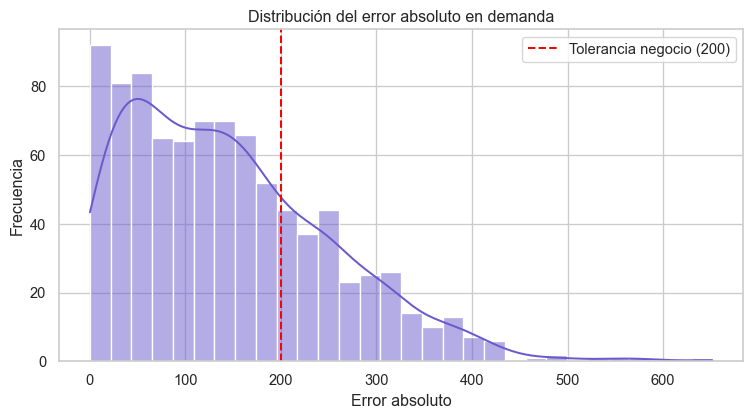

In [8]:
plt.figure(figsize=(8, 4.5))
sns.histplot(error_abs, bins=30, kde=True, color='slateblue')
plt.axvline(200, color='red', linestyle='--', label='Tolerancia negocio (200)')
plt.title('Distribución del error absoluto en demanda')
plt.xlabel('Error absoluto')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Traducción a Recomendación Ejecutiva

### ¿Qué es?
Es la etapa donde transformas resultados técnicos en un mensaje claro para decision makers.

### ¿Para qué sirve?
Porque los stakeholders no necesitan ver todo el detalle matemático, sino:
- qué decisión tomar
- por qué esa decisión es razonable
- cuál es el impacto esperado

### ¿Cómo se usa?
Armaremos un resumen corto con KPIs accionables:
- umbral recomendado
- costo estimado
- casos detectados/no detectados
- precision y recall de la estrategia elegida

Este formato es ideal para comités, jefaturas o presentaciones ejecutivas.

In [9]:
pred_best = (proba_test >= best_t).astype(int)
cm_best = confusion_matrix(y_test, pred_best)
fn = cm_best[1, 0]
tp = cm_best[1, 1]

resumen_ejecutivo = pd.DataFrame({
    'KPI': [
        'Umbral recomendado',
        'Costo total estimado',
        'Clientes churn detectados (TP)',
        'Churn no detectado (FN)',
        'Precisión',
        'Recall'
    ],
    'Valor': [
        f'{best_t:.2f}',
        f'USD {int(costo_total(y_test, pred_best, costo_fn, costo_fp)):,}',
        int(tp),
        int(fn),
        round(precision_score(y_test, pred_best, zero_division=0), 3),
        round(recall_score(y_test, pred_best, zero_division=0), 3)
    ]
})

resumen_ejecutivo

,KPI,Valor
0,Umbral recomendado,0.10
1,Costo total estimado,"USD 17,055"
2,Clientes churn detectados (TP),22
3,Churn no detectado (FN),59
4,Precisión,0.119
5,Recall,0.272


> El resumen ya no es una tabla vacía: con el umbral elegido por costo, el modelo **sí detecta churn real**, y podemos cuantificar cuántos casos se escapan (FN) y a qué costo. Ese es el lenguaje que entiende un comité: no *"recall = 0.27"*, sino *"detectamos N clientes en riesgo por X dólares, y se nos escapan M"*.

## 5. Ejercicio Práctico Integrador

### ¿Qué es?
Una simulación de decisión ejecutiva donde cambian las reglas de costo del negocio.

### ¿Para qué sirve?
Te entrena para adaptar el modelo a distintos contextos:
- crisis de retención (FN más costoso)
- presupuesto limitado (FP más costoso)

### Instrucciones
1. Cambia costos a: FN=300 y FP=15
2. Recalcula el mejor umbral
3. Compara con el umbral actual
4. Escribe una recomendación ejecutiva en 5 líneas

Sugerencia: explica explícitamente el trade-off entre recall y costo total.

In [10]:
costo_fn_2 = 300
costo_fp_2 = 15

registros_2 = []
for t in umbrales:
    pred_t = (proba_test >= t).astype(int)
    registros_2.append({
        'umbral': round(t, 2),
        'costo_total_usd': costo_total(y_test, pred_t, costo_fn_2, costo_fp_2)
    })

df_umb_2 = pd.DataFrame(registros_2)
best2 = df_umb_2.sort_values('costo_total_usd').iloc[0]

print('Mejor umbral escenario original:', best_t)
print('Mejor umbral escenario nuevo:   ', float(best2['umbral']))
print('Costo mínimo nuevo (USD):', int(best2['costo_total_usd']))

Mejor umbral escenario original: 0.1
Mejor umbral escenario nuevo:    0.05
Costo mínimo nuevo (USD): 17610


## Glosario de referencia

| Concepto | Qué es |
|---|---|
| Accuracy | % de aciertos (engaña con clases raras) |
| Precision / Recall | Calidad / cobertura de los positivos |
| F1 | Equilibrio entre precision y recall |
| ROC AUC | Capacidad de ordenar por riesgo (0.5 = azar) |
| Umbral de decisión | El corte que convierte probabilidad en decisión |
| Falso positivo / negativo | Alarma falsa / caso no detectado |
| Función de costo | Cuánto cuesta cada tipo de error |
| MAE / RMSE / R² | Métricas de error en regresión |
| Recomendación ejecutiva | Traducir métricas a una decisión accionable |

## Cierre

En este notebook aprendiste:
- Elegir métricas según el objetivo de negocio (y por qué el accuracy, solo, engaña con clases raras)
- Que un `recall = 0` no siempre significa un mal modelo: a veces solo hay que **mover el umbral**
- Ajustar el umbral con una **función de costo** para minimizar el impacto económico
- Traducir métricas técnicas en KPIs para una recomendación ejecutiva

Junto con el notebook 14 (reequilibrar clases con `class_weight`), ya cuentas con las dos palancas principales para trabajar con datos desbalanceados. El siguiente paso natural es aplicar todo esto en los proyectos aplicados del curso.

---
<p style="color:#898781;font-size:12px">Data Analytics Básico · Módulo 16 — Análisis avanzado</p>